<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/main/Project/Model_Code/TEST1_catboost_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 26.9 MB/s eta 0:00:00


In [ ]:
# @title
# ============================================================================
# EXPERIMENT: QUANTILE-BASED CLASSIFIER (FIXED + NORMALIZED)
# ============================================================================
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files
import os

# 1. LOAD DATA
print("="*60)
print("PREPARING QUANTILE EXPERIMENT")
print("="*60)

# Reload data to ensure fresh start
df_full = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather')

df_final = df_full.copy()

# 2. CREATE QUANTILE TARGETS
print("\nGenerating Quantile Targets (Splitting data into 4 equal groups)...")

# Calculate bins and assign labels
df_final['los_category_quantile'], bins = pd.qcut(
    df_final['length_of_stay'],
    q=4,
    labels=[0, 1, 2, 3],
    retbins=True,
    duplicates='drop'
)

# Print clean class definitions
print("\nNEW CATEGORY DEFINITIONS:")
print(f"  Class 0 (0-25%):   {bins[0]:.1f} to {bins[1]:.1f} days")
print(f"  Class 1 (25-50%):  {bins[1]:.1f} to {bins[2]:.1f} days")
print(f"  Class 2 (50-75%):  {bins[2]:.1f} to {bins[3]:.1f} days")
print(f"  Class 3 (75-100%): {bins[3]:.1f} to {bins[4]:.1f} days")

# Show class distribution
print("\nClass Distribution:")
print(df_final['los_category_quantile'].value_counts().sort_index())

# 3. PREPARE FEATURES (FIXED - REMOVED DUPLICATES)
cat_features_final = [
    'health_service_area',
    'hospital_county',
    'facility_id',
    'age_group',
    'zip_code',
    'gender',
    'race',
    'ethnicity',
    'admission_type',
    'ccsr_dx_code',
    'ccsr_px_code',
    'apr_drg_code',
    'apr_mdc_code',
    'apr_severity_code',
    'apr_mortality_risk',
    'apr_med_surg_desc',
    'payment_type'
]

feature_cols_final = cat_features_final + ['num_payment_types']

print(f"\nTotal features: {len(feature_cols_final)}")
print(f"Categorical features: {len(cat_features_final)}")
print(f"Numerical features: 1 (num_payment_types)")

# 4. SPLIT
X = df_final[feature_cols_final]
y = df_final['los_category_quantile']

print("\nSPLITTING DATA...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")

# 5. TRAIN (BEAST MODE SETTINGS)
print("\nTRAINING QUANTILE CLASSIFIER...")
train_pool = Pool(X_train, y_train, cat_features=cat_features_final)
test_pool = Pool(X_test, y_test, cat_features=cat_features_final)

final_clf = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.04,
    depth=10,
    l2_leaf_reg=7,
    border_count=254,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=200,
    verbose=500,
    random_state=42
)

final_clf.fit(train_pool, eval_set=test_pool)

# 6. EVALUATE
print("\n" + "="*60)
print("QUANTILE CLASSIFICATION RESULTS")
print("="*60)

y_pred = final_clf.predict(X_test)
y_pred_proba = final_clf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {acc:.2%}")
print("(Note: Random guessing would be 25%, so >50% is excellent)")

# Safely create labels for the report
label_q1 = f'Q1 ({bins[0]:.0f}-{bins[1]:.0f}d)'
label_q2 = f'Q2 ({bins[1]:.0f}-{bins[2]:.0f}d)'
label_q3 = f'Q3 ({bins[2]:.0f}-{bins[3]:.0f}d)'
label_q4 = f'Q4 ({bins[3]:.0f}-{bins[4]:.0f}d)'
target_names = [label_q1, label_q2, label_q3, label_q4]

print("\n" + classification_report(y_test, y_pred, target_names=target_names))

# ==================== CONFUSION MATRICES (RAW + NORMALIZED) ====================
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')  # Normalize by row (true labels)

# Create download directory
os.makedirs('/content/downloads', exist_ok=True)

# Plot 1: Raw Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names, ax=ax,
            cbar_kws={'label': 'Count'})
plt.title(f'Quantile Confusion Matrix - Raw Counts\n(Accuracy: {acc:.2%})',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/downloads/quantile_confusion_matrix_raw.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: /content/downloads/quantile_confusion_matrix_raw.png")
plt.show()
plt.close()

# Plot 2: Normalized Confusion Matrix (by row - shows recall per class)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names, ax=ax,
            cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
plt.title(f'Quantile Confusion Matrix - Normalized by Row\n(Accuracy: {acc:.2%})',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Add text annotations showing percentages
for i in range(len(cm_normalized)):
    for j in range(len(cm_normalized)):
        text = ax.text(j + 0.5, i + 0.5, f'{cm_normalized[i, j]:.1%}',
                      ha='center', va='center',
                      color='white' if cm_normalized[i, j] > 0.5 else 'black',
                      fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/downloads/quantile_confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/quantile_confusion_matrix_normalized.png")
plt.show()
plt.close()

# Plot 3: Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Quantile Confusion Matrix Comparison (Accuracy: {acc:.2%})',
             fontsize=16, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1],
            cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
axes[1].set_title('Normalized by Row (Recall)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/downloads/quantile_confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/quantile_confusion_matrix_comparison.png")
plt.show()
plt.close()

# Additional visualizations
# 1. Per-class accuracy
fig, ax = plt.subplots(figsize=(10, 6))
class_accuracies = []
for i in range(4):
    mask = y_test == i
    class_acc = accuracy_score(y_test[mask], y_pred[mask])
    class_accuracies.append(class_acc)

bars = ax.bar(range(4), class_accuracies, color=['#8B4789', '#9B59B6', '#BB79C6', '#CB99D6'],
              edgecolor='black', linewidth=2, alpha=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels(target_names, rotation=15, ha='right')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, acc_val) in enumerate(zip(bars, class_accuracies)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc_val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/downloads/quantile_class_accuracy.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/quantile_class_accuracy.png")
plt.show()
plt.close()

# 2. Feature importance
feature_importance = pd.DataFrame({
    'feature': final_clf.feature_names_,
    'importance': final_clf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
top_features = feature_importance.head(20)
ax.barh(range(len(top_features)), top_features['importance'],
        color='purple', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=10)
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Feature Importances (Quantile Classifier)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('/content/downloads/quantile_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/quantile_feature_importance.png")
plt.show()
plt.close()

# 7. SAVE MODEL
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

model_info = {
    'model': final_clf,
    'bins': bins,
    'target_names': target_names,
    'feature_cols': feature_cols_final,
    'cat_features': cat_features_final,
    'accuracy': acc,
    'class_accuracies': class_accuracies,
    'feature_importance': feature_importance,
    'confusion_matrix_raw': cm,
    'confusion_matrix_normalized': cm_normalized
}

joblib.dump(model_info, '/content/models/quantile_classifier.pkl')
print("✓ Model saved to: /content/models/quantile_classifier.pkl")

# 8. DOWNLOAD ALL FILES TO LOCAL MACHINE
print("\n" + "="*60)
print("DOWNLOADING FILES TO YOUR COMPUTER")
print("="*60)

download_files = [
    '/content/downloads/quantile_confusion_matrix_raw.png',
    '/content/downloads/quantile_confusion_matrix_normalized.png',
    '/content/downloads/quantile_confusion_matrix_comparison.png',
    '/content/downloads/quantile_class_accuracy.png',
    '/content/downloads/quantile_feature_importance.png'
]

for file_path in download_files:
    if os.path.exists(file_path):
        print(f"Downloading: {os.path.basename(file_path)}")
        files.download(file_path)
    else:
        print(f"⚠ File not found: {file_path}")

print("\n✓ All files downloaded to your Downloads folder!")

print("\n" + "="*60)
print("QUANTILE EXPERIMENT COMPLETE")
print("="*60)
print(f"\nFinal Accuracy: {acc:.2%}")
print("\nClass Accuracies:")
for name, acc_val in zip(target_names, class_accuracies):
    print(f"  {name}: {acc_val:.2%}")

# Print normalized confusion matrix as text
print("\n" + "="*60)
print("NORMALIZED CONFUSION MATRIX (by row)")
print("="*60)
print("\nRows = True Label, Columns = Predicted Label")
print("Values show % of true class predicted as each class\n")

cm_df = pd.DataFrame(cm_normalized,
                     index=target_names,
                     columns=target_names)
print(cm_df.applymap(lambda x: f'{x:.1%}').to_string())

PREPARING QUANTILE EXPERIMENT

Generating Quantile Targets (Splitting data into 4 equal groups)...

NEW CATEGORY DEFINITIONS:
  Class 0 (0-25%):   1.0 to 2.0 days
  Class 1 (25-50%):  2.0 to 3.0 days
  Class 2 (50-75%):  3.0 to 6.0 days
  Class 3 (75-100%): 6.0 to 120.0 days

Class Distribution:
los_category_quantile
0    1659056
1     644362
2     917494
3    1017724
Name: count, dtype: int64

Total features: 18
Categorical features: 17
Numerical features: 1 (num_payment_types)

SPLITTING DATA...
Train set: 3,814,772 samples
Test set:  423,864 samples

TRAINING QUANTILE CLASSIFIER...
0:	learn: 0.5245053	test: 0.5245008	best: 0.5245008 (0)	total: 61.3ms	remaining: 5m 6s
500:	learn: 0.5841741	test: 0.5829299	best: 0.5829299 (500)	total: 29.5s	remaining: 4m 24s
1000:	learn: 0.5914789	test: 0.5875658	best: 0.5875847 (999)	total: 59.2s	remaining: 3m 56s
1500:	learn: 0.5954261	test: 0.5895429	best: 0.5895641 (1490)	total: 1m 28s	remaining: 3m 25s


KeyboardInterrupt: 

PREPARING 3-CLASS CLASSIFIER

Generating 3-Class Targets (Short / Medium / Long)...

CLASS DEFINITIONS:
  Class 0 (Short):  1-2 days
  Class 1 (Medium): 3-7 days
  Class 2 (Long):   8+ days

Class Distribution:
los_category_3class
0    1659056
1    1733120
2     846460
Name: count, dtype: int64

Class Proportions:
los_category_3class
0    0.391413
1    0.408886
2    0.199701
Name: count, dtype: float64

Total features: 18
Categorical features: 17
Numerical features: 1 (num_payment_types)

SPLITTING DATA...
Train set: 3,814,772 samples
Test set:  423,864 samples

TRAINING 3-CLASS CLASSIFIER...
0:	learn: 0.5860940	test: 0.5871577	best: 0.5871577 (0)	total: 125ms	remaining: 10m 24s
500:	learn: 0.6548297	test: 0.6530302	best: 0.6530302 (500)	total: 26.5s	remaining: 3m 57s
1000:	learn: 0.6616034	test: 0.6581403	best: 0.6581498 (998)	total: 52.6s	remaining: 3m 30s
1500:	learn: 0.6655195	test: 0.6603321	best: 0.6603321 (1500)	total: 1m 18s	remaining: 3m 2s
2000:	learn: 0.6686211	test: 0.66164

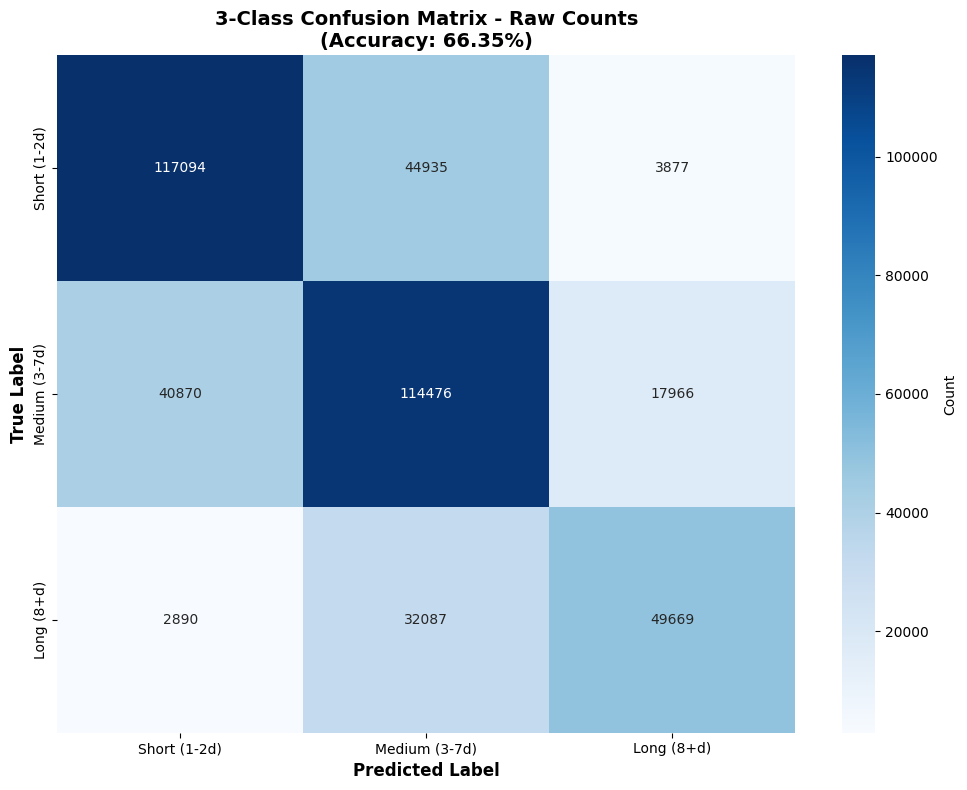

✓ Saved: /content/downloads/3class_confusion_matrix_normalized.png


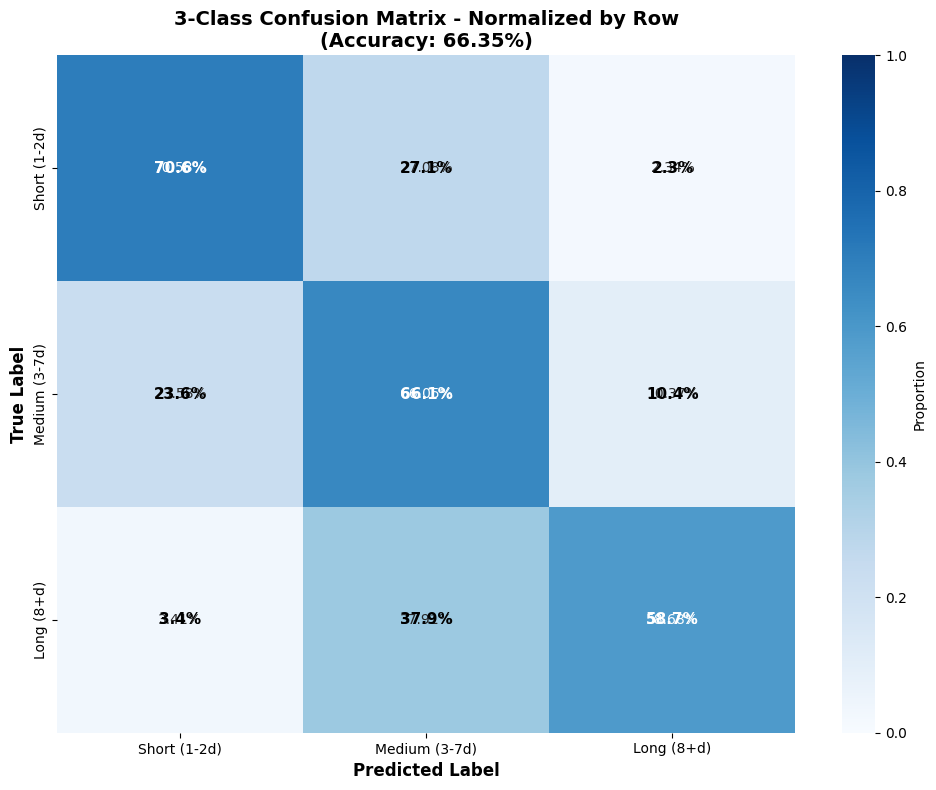

✓ Saved: /content/downloads/3class_confusion_matrix_comparison.png


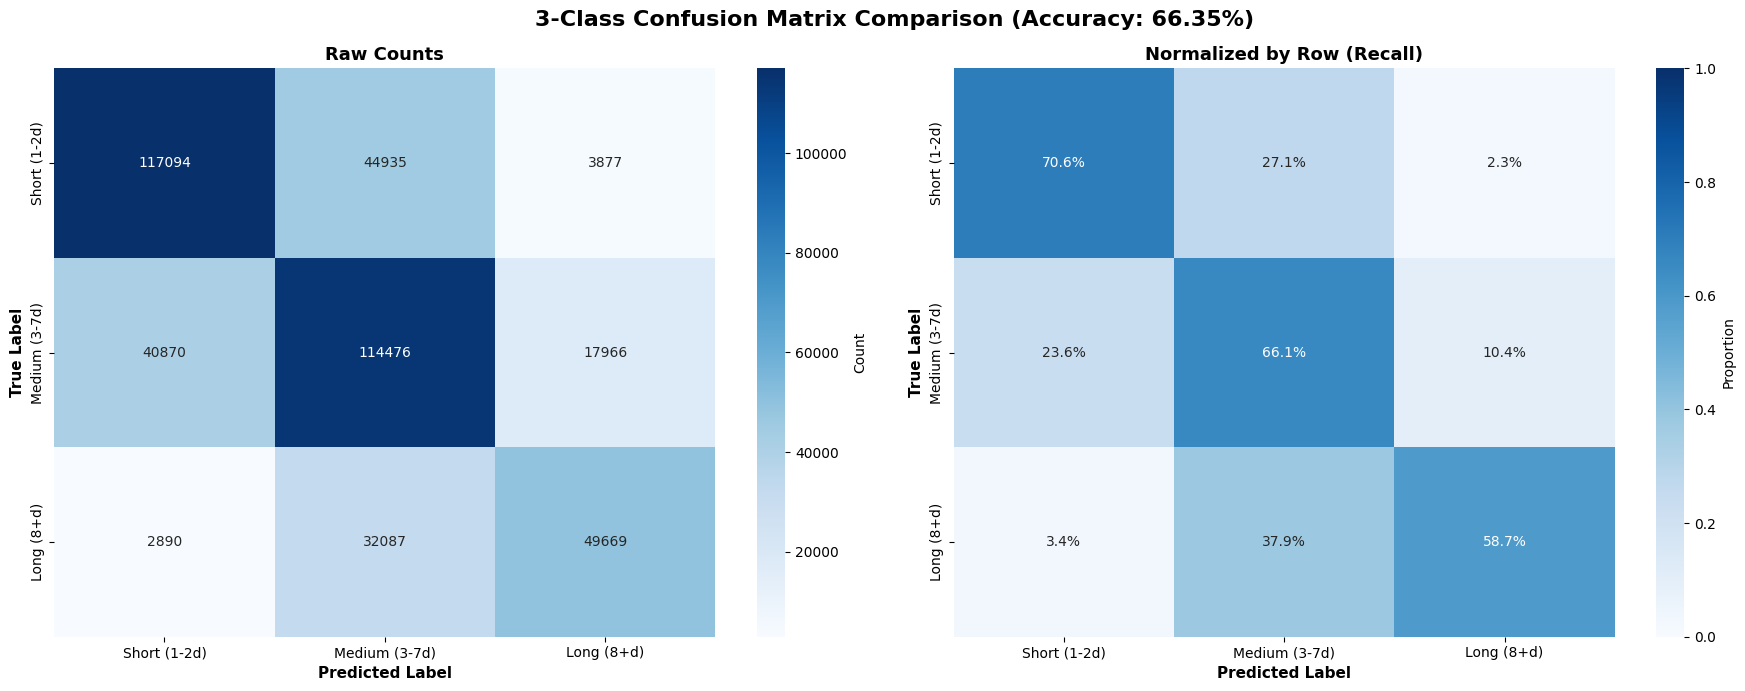


Generating per-class accuracy plot...


In [ ]:
# @title
# ============================================================================
# 3-CLASS CATBOOST CLASSIFIER: SHORT / MEDIUM / LONG STAY
# ============================================================================
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files
import os

# 1. LOAD DATA
print("="*60)
print("PREPARING 3-CLASS CLASSIFIER")
print("="*60)

# Reload data to ensure fresh start
df_full = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather')

df_final = df_full.copy()

# 2. CREATE 3-CLASS TARGET
print("\nGenerating 3-Class Targets (Short / Medium / Long)...")

def classify_los_3class(days):
    """
    Short: 1-2 days
    Medium: 3-7 days
    Long: 8+ days
    """
    if days <= 2:
        return 0  # Short
    elif days <= 7:
        return 1  # Medium
    else:
        return 2  # Long

df_final['los_category_3class'] = df_final['length_of_stay'].apply(classify_los_3class)

# Print class definitions and distribution
print("\nCLASS DEFINITIONS:")
print("  Class 0 (Short):  1-2 days")
print("  Class 1 (Medium): 3-7 days")
print("  Class 2 (Long):   8+ days")

print("\nClass Distribution:")
class_counts = df_final['los_category_3class'].value_counts().sort_index()
print(class_counts)
print("\nClass Proportions:")
print(class_counts / len(df_final))

# 3. PREPARE FEATURES (REMOVED DUPLICATES)
cat_features_final = [
    'health_service_area',
    'hospital_county',
    'facility_id',
    'age_group',
    'zip_code',
    'gender',
    'race',
    'ethnicity',
    'admission_type',
    'ccsr_dx_code',
    'ccsr_px_code',
    'apr_drg_code',
    'apr_mdc_code',
    'apr_severity_code',
    'apr_mortality_risk',
    'apr_med_surg_desc',
    'payment_type'
]

feature_cols_final = cat_features_final + ['num_payment_types']

print(f"\nTotal features: {len(feature_cols_final)}")
print(f"Categorical features: {len(cat_features_final)}")
print(f"Numerical features: 1 (num_payment_types)")

# 4. SPLIT
X = df_final[feature_cols_final]
y = df_final['los_category_3class']

print("\nSPLITTING DATA...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")

# 5. TRAIN (OPTIMIZED SETTINGS FOR 3-CLASS)
print("\nTRAINING 3-CLASS CLASSIFIER...")
train_pool = Pool(X_train, y_train, cat_features=cat_features_final)
test_pool = Pool(X_test, y_test, cat_features=cat_features_final)

clf_3class = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.04,
    depth=10,
    l2_leaf_reg=7,
    border_count=254,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=200,
    verbose=500,
    random_state=42
)

clf_3class.fit(train_pool, eval_set=test_pool)

# 6. EVALUATE
print("\n" + "="*60)
print("3-CLASS CLASSIFICATION RESULTS")
print("="*60)

y_pred = clf_3class.predict(X_test)
y_pred_proba = clf_3class.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {acc:.2%}")
print("(Note: Random guessing would be 33.3%)")

# Class labels
target_names = ['Short (1-2d)', 'Medium (3-7d)', 'Long (8+d)']

print("\n" + classification_report(y_test, y_pred, target_names=target_names))

# ==================== CONFUSION MATRICES (RAW + NORMALIZED) ====================
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')  # Normalize by row

# Create download directory
os.makedirs('/content/downloads', exist_ok=True)

# Plot 1: Raw Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax,
            cbar_kws={'label': 'Count'})
plt.title(f'3-Class Confusion Matrix - Raw Counts\n(Accuracy: {acc:.2%})',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/downloads/3class_confusion_matrix_raw.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: /content/downloads/3class_confusion_matrix_raw.png")
plt.show()
plt.close()

# Plot 2: Normalized Confusion Matrix (by row - shows recall per class)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax,
            cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
plt.title(f'3-Class Confusion Matrix - Normalized by Row\n(Accuracy: {acc:.2%})',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Add percentage annotations
for i in range(len(cm_normalized)):
    for j in range(len(cm_normalized)):
        text = ax.text(j + 0.5, i + 0.5, f'{cm_normalized[i, j]:.1%}',
                      ha='center', va='center',
                      color='white' if cm_normalized[i, j] > 0.5 else 'black',
                      fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/downloads/3class_confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/3class_confusion_matrix_normalized.png")
plt.show()
plt.close()

# Plot 3: Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'3-Class Confusion Matrix Comparison (Accuracy: {acc:.2%})',
             fontsize=16, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1],
            cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
axes[1].set_title('Normalized by Row (Recall)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/downloads/3class_confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/3class_confusion_matrix_comparison.png")
plt.show()
plt.close()

# ==================== ADDITIONAL VISUALIZATIONS ====================

# 1. Per-class accuracy
print("\nGenerating per-class accuracy plot...")
fig, ax = plt.subplots(figsize=(10, 6))
class_accuracies = []
class_precisions = []
class_recalls = []

for i in range(3):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_pred[mask])
        class_accuracies.append(class_acc)

        # Calculate precision and recall
        tp = ((y_test == i) & (y_pred == i)).sum()
        fp = ((y_test != i) & (y_pred == i)).sum()
        fn = ((y_test == i) & (y_pred != i)).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        class_precisions.append(precision)
        class_recalls.append(recall)

x = np.arange(3)
width = 0.25

bars1 = ax.bar(x - width, class_accuracies, width, label='Accuracy',
               color='#3498db', edgecolor='black', linewidth=2, alpha=0.8)
bars2 = ax.bar(x, class_precisions, width, label='Precision',
               color='#2ecc71', edgecolor='black', linewidth=2, alpha=0.8)
bars3 = ax.bar(x + width, class_recalls, width, label='Recall',
               color='#e74c3c', edgecolor='black', linewidth=2, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2%}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/downloads/3class_performance_metrics.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/3class_performance_metrics.png")
plt.show()
plt.close()

# 2. Class distribution comparison (Actual vs Predicted)
print("Generating class distribution comparison...")
fig, ax = plt.subplots(figsize=(10, 6))

actual_counts = [((y_test == i).sum()) for i in range(3)]
predicted_counts = [((y_pred == i).sum()) for i in range(3)]

x = np.arange(3)
width = 0.35

bars1 = ax.bar(x - width/2, actual_counts, width, label='Actual',
               color='#3498db', edgecolor='black', linewidth=2, alpha=0.8)
bars2 = ax.bar(x + width/2, predicted_counts, width, label='Predicted',
               color='#e74c3c', edgecolor='black', linewidth=2, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution: Actual vs Predicted', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/downloads/3class_distribution_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/3class_distribution_comparison.png")
plt.show()
plt.close()

# 3. Feature importance
print("Generating feature importance plot...")
feature_importance = pd.DataFrame({
    'feature': clf_3class.feature_names_,
    'importance': clf_3class.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
top_features = feature_importance.head(20)
ax.barh(range(len(top_features)), top_features['importance'],
        color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=10)
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Feature Importances (3-Class Classifier)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('/content/downloads/3class_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/3class_feature_importance.png")
plt.show()
plt.close()

# 4. Prediction probability distributions
print("Generating prediction probability distributions...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prediction Probability Distributions by True Class',
             fontsize=16, fontweight='bold')

colors = ['#3498db',  '#2ecc71', '#e74c3c']

for i in range(3):
    mask = y_test == i
    probas = y_pred_proba[mask][:, i]  # Probability of correct class

    axes[i].hist(probas, bins=50, color=colors[i], alpha=0.7,
                 edgecolor='black', linewidth=1.5)
    axes[i].axvline(probas.mean(), color='red', linestyle='--',
                    linewidth=2, label=f'Mean: {probas.mean():.2f}')
    axes[i].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[i].set_title(f'{target_names[i]}\n(n={mask.sum():,})',
                      fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/downloads/3class_probability_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: /content/downloads/3class_probability_distributions.png")
plt.show()
plt.close()

# 7. SAVE MODEL
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

model_info = {
    'model': clf_3class,
    'target_names': target_names,
    'feature_cols': feature_cols_final,
    'cat_features': cat_features_final,
    'accuracy': acc,
    'class_accuracies': class_accuracies,
    'class_precisions': class_precisions,
    'class_recalls': class_recalls,
    'feature_importance': feature_importance,
    'confusion_matrix_raw': cm,
    'confusion_matrix_normalized': cm_normalized
}

joblib.dump(model_info, '/content/3class_classifier.pkl')
print("✓ Model saved to: /content/3class_classifier.pkl")

# 8. DOWNLOAD ALL FILES TO LOCAL MACHINE
print("\n" + "="*60)
print("DOWNLOADING FILES TO YOUR COMPUTER")
print("="*60)

download_files = [
    '/content/downloads/3class_confusion_matrix_raw.png',
    '/content/downloads/3class_confusion_matrix_normalized.png',
    '/content/downloads/3class_confusion_matrix_comparison.png',
    '/content/downloads/3class_performance_metrics.png',
    '/content/downloads/3class_distribution_comparison.png',
    '/content/downloads/3class_feature_importance.png',
    '/content/downloads/3class_probability_distributions.png'
]

for file_path in download_files:
    if os.path.exists(file_path):
        print(f"Downloading: {os.path.basename(file_path)}")
        files.download(file_path)
    else:
        print(f"⚠ File not found: {file_path}")

print("\n✓ All files downloaded to your Downloads folder!")

print("\n" + "="*60)
print("3-CLASS CLASSIFICATION COMPLETE")
print("="*60)
print(f"\nFinal Accuracy: {acc:.2%}")
print("\nPer-Class Performance:")
for i, name in enumerate(target_names):
    print(f"  {name}:")
    print(f"    Accuracy:  {class_accuracies[i]:.2%}")
    print(f"    Precision: {class_precisions[i]:.2%}")
    print(f"    Recall:    {class_recalls[i]:.2%}")

# Print normalized confusion matrix as text
print("\n" + "="*60)
print("NORMALIZED CONFUSION MATRIX (by row)")
print("="*60)
print("\nRows = True Label, Columns = Predicted Label")
print("Values show % of true class predicted as each class\n")

cm_df = pd.DataFrame(cm_normalized,
                     index=target_names,
                     columns=target_names)
print(cm_df.applymap(lambda x: f'{x:.1%}').to_string())

In [ ]:
# ============================================================================
# 3-CLASS CATBOOST CLASSIFIER: SHORT / MEDIUM / LONG STAY
# ============================================================================
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files
import os

# 1. LOAD DATA
print("="*60)
print("PREPARING 3-CLASS CLASSIFIER")
print("="*60)

# Reload data to ensure fresh start
df_full = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather')

df_final = df_full.copy()

# 2. CREATE 3-CLASS TARGET
print("\nGenerating 3-Class Targets (Short / Medium / Long)...")

def classify_los_3class(days):
    """
    Short: 1-2 days
    Medium: 3-7 days
    Long: 8+ days
    """
    if days <= 2:
        return 0  # Short
    elif days <= 7:
        return 1  # Medium
    else:
        return 2  # Long

df_final['los_category_3class'] = df_final['length_of_stay'].apply(classify_los_3class)

# Print class definitions and distribution
print("\nCLASS DEFINITIONS:")
print("  Class 0 (Short):  1-2 days")
print("  Class 1 (Medium): 3-7 days")
print("  Class 2 (Long):   8+ days")

print("\nClass Distribution:")
class_counts = df_final['los_category_3class'].value_counts().sort_index()
print(class_counts)
print("\nClass Proportions:")
print(class_counts / len(df_final))

# 3. PREPARE FEATURES (REMOVED DUPLICATES)
cat_features_final = [
    'health_service_area',
    'hospital_county',
    'facility_id',
    'age_group',
    'zip_code',
    'gender',
    'race',
    'ethnicity',
    'admission_type',
    'ccsr_dx_code',
    'ccsr_px_code',
    'apr_drg_code',
    'apr_mdc_code',
    'apr_severity_code',
    'apr_mortality_risk',
    'apr_med_surg_desc',
    'payment_type'
]

feature_cols_final = cat_features_final + ['num_payment_types']

print(f"\nTotal features: {len(feature_cols_final)}")
print(f"Categorical features: {len(cat_features_final)}")
print(f"Numerical features: 1 (num_payment_types)")

# 4. SPLIT
X = df_final[feature_cols_final]
y = df_final['los_category_3class']

print("\nSPLITTING DATA...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")

# 5. TRAIN (OPTIMIZED SETTINGS FOR 3-CLASS)
print("\nTRAINING 3-CLASS CLASSIFIER...")
train_pool = Pool(X_train, y_train, cat_features=cat_features_final)
test_pool = Pool(X_test, y_test, cat_features=cat_features_final)

clf_3class = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.04,
    depth=10,
    l2_leaf_reg=7,
    border_count=254,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=200,
    verbose=500,
    random_state=42
)

clf_3class.fit(train_pool, eval_set=test_pool)

# 6. EVALUATE
print("\n" + "="*60)
print("3-CLASS CLASSIFICATION RESULTS")
print("="*60)

y_pred = clf_3class.predict(X_test)
y_pred_proba = clf_3class.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {acc:.2%}")
print("(Note: Random guessing would be 33.3%)")

# Class labels
target_names = ['Short (1-2d)', 'Medium (3-7d)', 'Long (8+d)']

print("\n" + classification_report(y_test, y_pred, target_names=target_names))

# Confusion matrices (needed for model_info) and other metrics
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Calculate per-class metrics (needed for model_info)
class_accuracies = []
class_precisions = []
class_recalls = []

for i in range(3):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_pred[mask])
        class_accuracies.append(class_acc)

        tp = ((y_test == i) & (y_pred == i)).sum()
        fp = ((y_test != i) & (y_pred == i)).sum()
        fn = ((y_test == i) & (y_pred != i)).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        class_precisions.append(precision)
        class_recalls.append(recall)

# Feature importance (needed for model_info)
feature_importance = pd.DataFrame({
    'feature': clf_3class.feature_names_,
    'importance': clf_3class.feature_importances_
}).sort_values('importance', ascending=False)

# 7. SAVE MODEL
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

model_info = {
    'model': clf_3class,
    'target_names': target_names,
    'feature_cols': feature_cols_final,
    'cat_features': cat_features_final,
    'accuracy': acc,
    'class_accuracies': class_accuracies,
    'class_precisions': class_precisions,
    'class_recalls': class_recalls,
    'feature_importance': feature_importance,
    'confusion_matrix_raw': cm,
    'confusion_matrix_normalized': cm_normalized
}

joblib.dump(model_info, '/content/3class_classifier.pkl')
print("✓ Model saved to: /content/3class_classifier.pkl")

PREPARING 3-CLASS CLASSIFIER

Generating 3-Class Targets (Short / Medium / Long)...

CLASS DEFINITIONS:
  Class 0 (Short):  1-2 days
  Class 1 (Medium): 3-7 days
  Class 2 (Long):   8+ days

Class Distribution:
los_category_3class
0    1659056
1    1733120
2     846460
Name: count, dtype: int64

Class Proportions:
los_category_3class
0    0.391413
1    0.408886
2    0.199701
Name: count, dtype: float64

Total features: 18
Categorical features: 17
Numerical features: 1 (num_payment_types)

SPLITTING DATA...
Train set: 3,814,772 samples
Test set:  423,864 samples

TRAINING 3-CLASS CLASSIFIER...
0:	learn: 0.5860940	test: 0.5871577	best: 0.5871577 (0)	total: 55.8ms	remaining: 4m 38s
500:	learn: 0.6548294	test: 0.6530326	best: 0.6530326 (500)	total: 25.5s	remaining: 3m 49s
1000:	learn: 0.6615845	test: 0.6581687	best: 0.6581687 (1000)	total: 50.7s	remaining: 3m 22s
1500:	learn: 0.6655360	test: 0.6603510	best: 0.6603557 (1498)	total: 1m 15s	remaining: 2m 56s
2000:	learn: 0.6685820	test: 0.661

In [ ]:
# ============================================================================
# 3-CLASS CATBOOST CLASSIFIER: SHORT / MEDIUM / LONG STAY
# OPTIMIZED FOR QUICK SAVE - MINIMAL VERSION
# ============================================================================
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import joblib

# 1. LOAD DATA
print("="*60)
print("PREPARING 3-CLASS CLASSIFIER")
print("="*60)

df_full = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather')
df_final = df_full.copy()

# 2. CREATE 3-CLASS TARGET
print("\nGenerating 3-Class Targets (Short / Medium / Long)...")

def classify_los_3class(days):
    if days <= 2:
        return 0  # Short
    elif days <= 7:
        return 1  # Medium
    else:
        return 2  # Long

df_final['los_category_3class'] = df_final['length_of_stay'].apply(classify_los_3class)

print("\nClass Distribution:")
print(df_final['los_category_3class'].value_counts().sort_index())

# 3. PREPARE FEATURES
cat_features_final = [
    'health_service_area',
    'hospital_county',
    'facility_id',
    'age_group',
    'zip_code',
    'gender',
    'race',
    'ethnicity',
    'admission_type',
    'ccsr_dx_code',
    'ccsr_px_code',
    'apr_drg_code',
    'apr_mdc_code',
    'apr_severity_code',
    'apr_mortality_risk',
    'apr_med_surg_desc',
    'payment_type'
]

feature_cols_final = cat_features_final + ['num_payment_types']

# 4. SPLIT
X = df_final[feature_cols_final]
y = df_final['los_category_3class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

# 5. TRAIN
print("\nTRAINING 3-CLASS CLASSIFIER...")
train_pool = Pool(X_train, y_train, cat_features=cat_features_final)
test_pool = Pool(X_test, y_test, cat_features=cat_features_final)

clf_3class = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.04,
    depth=10,
    l2_leaf_reg=7,
    border_count=254,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=200,
    verbose=500,
    random_state=42
)

clf_3class.fit(train_pool, eval_set=test_pool)

# 6. SAVE IMMEDIATELY - NO METRICS CALCULATION
print("\n" + "="*60)
print("SAVING MODEL (MINIMAL VERSION)")
print("="*60)

model_info = {
    'model': clf_3class,
    'feature_cols': feature_cols_final,
    'cat_features': cat_features_final
}

# Save to Google Drive directly
joblib.dump(model_info, '/content/drive/MyDrive/3class_classifier.pkl')
print("✓ Model saved to Google Drive: /content/drive/MyDrive/3class_classifier.pkl")

# Also save locally as backup
joblib.dump(model_info, '/content/3class_classifier.pkl')
print("✓ Backup saved locally: /content/3class_classifier.pkl")

print("\n✓✓✓ MODEL SAVED SUCCESSFULLY ✓✓✓")
print("You can now calculate metrics separately using the saved model.")

PREPARING 3-CLASS CLASSIFIER

Generating 3-Class Targets (Short / Medium / Long)...

Class Distribution:
los_category_3class
0    1659056
1    1733120
2     846460
Name: count, dtype: int64

Train: 3,814,772 | Test: 423,864

TRAINING 3-CLASS CLASSIFIER...
0:	learn: 0.5860940	test: 0.5871577	best: 0.5871577 (0)	total: 123ms	remaining: 10m 13s
500:	learn: 0.6548294	test: 0.6530326	best: 0.6530326 (500)	total: 26.3s	remaining: 3m 55s
1000:	learn: 0.6615845	test: 0.6581687	best: 0.6581687 (1000)	total: 51.6s	remaining: 3m 26s
1500:	learn: 0.6655129	test: 0.6601811	best: 0.6602401 (1472)	total: 1m 17s	remaining: 2m 59s
2000:	learn: 0.6685860	test: 0.6614221	best: 0.6614221 (2000)	total: 1m 42s	remaining: 2m 33s
2500:	learn: 0.6713848	test: 0.6625191	best: 0.6625191 (2500)	total: 2m 8s	remaining: 2m 7s
3000:	learn: 0.6741158	test: 0.6629084	best: 0.6629792 (2997)	total: 2m 33s	remaining: 1m 42s
3500:	learn: 0.6764931	test: 0.6632906	best: 0.6634180 (3458)	total: 2m 59s	remaining: 1m 16s
4000

##**CATBOOST FIRST TEST REGRESSOR**

In [ ]:
# ============================================================================
# OPTIMIZED CATBOOST REGRESSOR FOR LOG(LOS+1)
# FULL PIPELINE WITH OVERFITTING CHECK (80/20 SPLIT)
# INCLUDES NORMALIZED VISUALIZATIONS AND AUTO-DOWNLOAD
# ============================================================================
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
from google.colab import files
import joblib

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("LOADING DATA...")
print("="*60)

df_full = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather')
print(f"Loaded {len(df_full):,} rows")
df_final = df_full.copy()

# ============================================================================
# DEFINE FEATURES
# ============================================================================
cat_features_final = [
    'health_service_area', 'hospital_county', 'facility_id', 'age_group',
    'zip_code', 'gender', 'race', 'ethnicity', 'admission_type',
    'ccsr_dx_code', 'ccsr_px_code', 'apr_drg_code', 'apr_mdc_code',
    'apr_severity_code', 'apr_mortality_risk', 'apr_med_surg_desc',
    'payment_type'
]

feature_cols_final = cat_features_final + ['num_payment_types']
print(f"\nFeatures used: {len(feature_cols_final)}")
print(f"  Categorical: {len(cat_features_final)}")
print(f"  Numerical: 1 (num_payment_types)")

# ============================================================================
# PREPARE DATA (LOG-TRANSFORMED TARGET)
# ============================================================================
X = df_final[feature_cols_final]
y = df_final['length_of_stay']

print("\n" + "="*60)
print("SPLITTING DATA (80% Train / 20% Test)...")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")

# Log transform targets
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Create CatBoost pools
train_pool = Pool(X_train, y_train_log, cat_features=cat_features_final)
test_pool = Pool(X_test, y_test_log, cat_features=cat_features_final)

# ============================================================================
# OPTIMIZED CATBOOST MODEL FOR LOG LOS
# ============================================================================
print("\n" + "="*60)
print("TRAINING OPTIMIZED CATBOOST MODEL (LOG LOS)...")
print("="*60)

optimized_model = CatBoostRegressor(
    iterations=2500,
    depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    l2_leaf_reg=12,
    subsample=0.8,
    bootstrap_type="MVS",
    bagging_temperature=1,
    border_count=128,
    task_type="GPU",
    devices='0',
    early_stopping_rounds=150,
    random_seed=42,
    verbose=200
)

optimized_model.fit(train_pool, eval_set=test_pool)

# ============================================================================
# SAVE MODEL
# ============================================================================
print("\n" + "="*60)
print("SAVING MODEL...")
print("="*60)

optimized_model.save_model('/content/optimized_catboost_loglos.cbm')
print("✓ Model saved to: /content/optimized_catboost_loglos.cbm")




LOADING DATA...
Loaded 4,238,636 rows

Features used: 18
  Categorical: 17
  Numerical: 1 (num_payment_types)

SPLITTING DATA (80% Train / 20% Test)...
Train set: 3,390,908 samples
Test set:  847,728 samples

TRAINING OPTIMIZED CATBOOST MODEL (LOG LOS)...
0:	learn: 0.7249222	test: 0.7260871	best: 0.7260871 (0)	total: 139ms	remaining: 5m 46s
200:	learn: 0.5670815	test: 0.5670021	best: 0.5670021 (200)	total: 16.2s	remaining: 3m 5s
400:	learn: 0.5366550	test: 0.5363780	best: 0.5363780 (400)	total: 32.9s	remaining: 2m 52s
600:	learn: 0.5267815	test: 0.5262178	best: 0.5262178 (600)	total: 49.4s	remaining: 2m 36s
800:	learn: 0.5207524	test: 0.5200287	best: 0.5200287 (800)	total: 1m 5s	remaining: 2m 18s
1000:	learn: 0.5162710	test: 0.5154521	best: 0.5154521 (1000)	total: 1m 21s	remaining: 2m 1s
1200:	learn: 0.5134968	test: 0.5125420	best: 0.5125420 (1200)	total: 1m 36s	remaining: 1m 44s
1400:	learn: 0.5116596	test: 0.5106807	best: 0.5106807 (1400)	total: 1m 51s	remaining: 1m 27s
1600:	learn: 

In [ ]:
# ============================================================================
# EVALUATION (BACK-TRANSFORM + CLIP NEGATIVE PREDICTIONS)
# ============================================================================
print("\n" + "="*60)
print("EVALUATING PERFORMANCE...")
print("="*60)

# Predictions in log-space
y_test_pred_log = optimized_model.predict(X_test)
y_train_pred_log = optimized_model.predict(X_train)

# Back-transform to original scale
y_test_pred_raw = np.expm1(y_test_pred_log)
y_train_pred_raw = np.expm1(y_train_pred_log)

# 🔥 Clip negative predictions to 0
y_test_pred = np.maximum(y_test_pred_raw, 0)
y_train_pred = np.maximum(y_train_pred_raw, 0)

num_negative_test = (y_test_pred_raw < 0).sum()
num_negative_train = (y_train_pred_raw < 0).sum()

print(f"\nNegative predictions corrected:")
print(f"  Train: {num_negative_train:,}")
print(f"  Test:  {num_negative_test:,}")

# Calculate metrics
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)

train_mae  = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2   = r2_score(y_train, y_train_pred)

print("\n" + "="*60)
print("   FINAL MODEL PERFORMANCE")
print("="*60)
print(f"\nTest Set:")
print(f"  MAE:  {test_mae:.3f} days")
print(f"  RMSE: {test_rmse:.3f} days")
print(f"  R²:   {test_r2:.4f}")

# ============================================================================
# OVERFITTING CHECK
# ============================================================================
print("\n" + "="*60)
print("OVERFITTING CHECK")
print("="*60)

print("\nTraining Set:")
print(f"  MAE:  {train_mae:.3f} days")
print(f"  RMSE: {train_rmse:.3f} days")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Set:")
print(f"  MAE:  {test_mae:.3f} days")
print(f"  RMSE: {test_rmse:.3f} days")
print(f"  R²:   {test_r2:.4f}")

# Calculate gaps
mae_gap  = test_mae - train_mae
rmse_gap = test_rmse - train_rmse
r2_gap   = train_r2 - test_r2

print("\nOverfitting Indicators:")
print(f"  MAE gap:  {mae_gap:+.3f} days ({(mae_gap/train_mae)*100:+.1f}%)")
print(f"  RMSE gap: {rmse_gap:+.3f} days ({(rmse_gap/train_rmse)*100:+.1f}%)")
print(f"  R² gap:   {r2_gap:+.3f} ({(r2_gap/train_r2)*100:+.1f}%)")

# Assessment
if mae_gap < 0.2 and r2_gap < 0.02:
    assessment = "✓ No Overfitting - Model generalizes well!"
elif mae_gap < 0.5 and r2_gap < 0.05:
    assessment = "✓ Minimal Overfitting - Acceptable for production"
elif mae_gap < 1.0 and r2_gap < 0.10:
    assessment = "⚠ Moderate Overfitting - Consider regularization"
else:
    assessment = "⚠ Significant Overfitting - Model needs adjustment"

print(f"\n{assessment}")


EVALUATING PERFORMANCE...

Negative predictions corrected:
  Train: 5
  Test:  1

   FINAL MODEL PERFORMANCE

Test Set:
  MAE:  2.889 days
  RMSE: 6.961 days
  R²:   0.3676

OVERFITTING CHECK

Training Set:
  MAE:  2.863 days
  RMSE: 6.933 days
  R²:   0.3699

Test Set:
  MAE:  2.889 days
  RMSE: 6.961 days
  R²:   0.3676

Overfitting Indicators:
  MAE gap:  +0.026 days (+0.9%)
  RMSE gap: +0.027 days (+0.4%)
  R² gap:   +0.002 (+0.6%)

✓ No Overfitting - Model generalizes well!


In [ ]:

# ============================================================================
# VISUALIZATION SETUP
# ============================================================================
output_dir = "/content/downloads/"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Use clipped predictions for all visualizations
y_pred_final = y_test_pred

# Create LOS categories for analysis
def categorize_los(days):
    if days <= 2:
        return 0
    elif days <= 7:
        return 1
    elif days <= 14:
        return 2
    else:
        return 3

y_test_category = y_test.apply(categorize_los)
category_names = ['Short (1-2d)', 'Moderate (3-7d)', 'Long (8-14d)', 'Extreme (15+d)']

# ============================================================================
# 1. PREDICTED VS ACTUAL
# ============================================================================
print("\n[1/8] Predicted vs Actual...")

fig, ax = plt.subplots(figsize=(10, 10))

# Sample for performance if needed
if len(y_test) > 50000:
    idx = np.random.choice(len(y_test), 50000, replace=False)
    y_true_plot = y_test.iloc[idx]
    y_pred_plot = y_pred_final[idx]
else:
    y_true_plot = y_test
    y_pred_plot = y_pred_final

# Create density coloring
xy = np.vstack([y_true_plot, y_pred_plot])
z = stats.gaussian_kde(xy)(xy)
idx_sort = z.argsort()

scatter = ax.scatter(
    y_true_plot.iloc[idx_sort],
    y_pred_plot[idx_sort],
    c=z[idx_sort], cmap='viridis', s=15, alpha=0.5
)

# Perfect prediction line
max_val = max(y_test.max(), y_pred_final.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel("Actual LOS (days)", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted LOS (days)", fontsize=12, fontweight='bold')
ax.set_title(f"Predicted vs Actual LOS\nMAE: {test_mae:.3f} days | R²: {test_r2:.4f}",
             fontsize=15, fontweight='bold')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label="Point Density")
plt.tight_layout()
plt.savefig(f"{output_dir}01_predicted_vs_actual.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 01_predicted_vs_actual.png")

# ============================================================================
# 2. RESIDUAL ANALYSIS
# ============================================================================
print("[2/8] Residual Analysis...")

residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Residual Analysis — Optimized CatBoost", fontsize=16, fontweight='bold')

# Sample for performance
if len(residuals) > 50000:
    idx = np.random.choice(len(residuals), 50000, replace=False)
    residuals_plot = residuals[idx]
    y_pred_plot = y_pred_final[idx]
else:
    residuals_plot = residuals
    y_pred_plot = y_pred_final

# 2A: Residuals vs Predicted
axes[0,0].scatter(y_pred_plot, residuals_plot, alpha=0.3, s=8, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel("Predicted LOS (days)", fontweight='bold')
axes[0,0].set_ylabel("Residuals (days)", fontweight='bold')
axes[0,0].set_title("Residuals vs Predicted", fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# 2B: Histogram
axes[0,1].hist(residuals, bins=100, alpha=0.7, edgecolor='black', color='steelblue')
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_xlabel("Residuals (days)", fontweight='bold')
axes[0,1].set_ylabel("Frequency", fontweight='bold')
axes[0,1].set_title("Residual Distribution", fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='y')

# Add statistics
mean_res = np.mean(residuals)
std_res = np.std(residuals)
axes[0,1].text(0.02, 0.98, f'Mean: {mean_res:.3f}\nStd: {std_res:.3f}',
               transform=axes[0,1].transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2C: Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title("Normal Q-Q Plot", fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 2D: Absolute Residuals vs Predicted
axes[1,1].scatter(y_pred_plot, np.abs(residuals_plot), alpha=0.3, s=8, color='steelblue')
axes[1,1].set_xlabel("Predicted LOS (days)", fontweight='bold')
axes[1,1].set_ylabel("Absolute Residuals (days)", fontweight='bold')
axes[1,1].set_title("Absolute Residuals vs Predicted", fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}02_residual_analysis.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 02_residual_analysis.png")

# ============================================================================
# 3. PERFORMANCE BY CATEGORY (NORMALIZED)
# ============================================================================
print("[3/8] Performance by Category...")

metrics = []
for cat in range(4):
    mask = (y_test_category == cat)
    if mask.sum() > 0:
        mae = mean_absolute_error(y_test[mask], y_pred_final[mask])
        rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred_final[mask]))
        r2 = r2_score(y_test[mask], y_pred_final[mask])
        n = mask.sum()
        metrics.append({
            "Category": category_names[cat],
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2,
            "N": n,
            "Proportion": n / len(y_test)
        })

df_metrics = pd.DataFrame(metrics)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Performance by LOS Category", fontsize=16, fontweight='bold')

colors = ['#2ecc71','#3498db','#f39c12','#e74c3c']

# Plot 1: MAE by Category
bars = axes[0,0].bar(df_metrics["Category"], df_metrics["MAE"],
                      color=colors, edgecolor='black', linewidth=2, alpha=0.8)
axes[0,0].set_ylabel("MAE (days)", fontweight='bold')
axes[0,0].set_title("Mean Absolute Error by Category", fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='y')
axes[0,0].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, df_metrics["MAE"]):
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                  f'{val:.2f}', ha='center', va='bottom',
                  fontsize=10, fontweight='bold')

# Plot 2: R² by Category
bars = axes[0,1].bar(df_metrics["Category"], df_metrics["R²"],
                      color=colors, edgecolor='black', linewidth=2, alpha=0.8)
axes[0,1].set_ylabel("R²", fontweight='bold')
axes[0,1].set_title("R² Score by Category", fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='y')
axes[0,1].set_ylim([0, 1])
axes[0,1].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, df_metrics["R²"]):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                  f'{val:.3f}', ha='center', va='bottom',
                  fontsize=10, fontweight='bold')

# Plot 3: Sample Count
bars = axes[1,0].bar(df_metrics["Category"], df_metrics["N"],
                      color=colors, edgecolor='black', linewidth=2, alpha=0.8)
axes[1,0].set_ylabel("Sample Count", fontweight='bold')
axes[1,0].set_title("Test Samples by Category", fontweight='bold')
axes[1,0].grid(True, alpha=0.3, axis='y')
axes[1,0].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, df_metrics["N"]):
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                  f'{val:,}', ha='center', va='bottom',
                  fontsize=10, fontweight='bold')

# Plot 4: Normalized Distribution (%)
bars = axes[1,1].bar(df_metrics["Category"], df_metrics["Proportion"]*100,
                      color=colors, edgecolor='black', linewidth=2, alpha=0.8)
axes[1,1].set_ylabel("Percentage of Test Set (%)", fontweight='bold')
axes[1,1].set_title("Distribution by Category (Normalized)", fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')
axes[1,1].set_ylim([0, 100])
axes[1,1].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, df_metrics["Proportion"]*100):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 1,
                  f'{val:.1f}%', ha='center', va='bottom',
                  fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{output_dir}03_performance_by_category.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 03_performance_by_category.png")

# ============================================================================
# 4. ERROR BY LOS BINS
# ============================================================================
print("[4/8] Error by LOS bins...")

errors = y_pred_final - y_test.values
bins = [0, 2, 4, 7, 14, 30, y_test.max()+1]
labels = ['0-2', '3-4', '5-7', '8-14', '15-30', '30+']
y_bin = pd.cut(y_test, bins=bins, labels=labels)

df_error = pd.DataFrame({
    "Bin": y_bin,
    "Error": errors,
    "Abs_Error": np.abs(errors)
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Error Distribution by Actual LOS Range", fontsize=16, fontweight='bold')

# Plot 1: Error distribution
sns.boxplot(x="Bin", y="Error", data=df_error, ax=axes[0], palette='Set2')
axes[0].axhline(0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel("Actual LOS Range (days)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Prediction Error (days)", fontsize=12, fontweight='bold')
axes[0].set_title("Error Distribution (Predicted - Actual)", fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Absolute error distribution
sns.boxplot(x="Bin", y="Abs_Error", data=df_error, ax=axes[1], palette='Set3')
axes[1].set_xlabel("Actual LOS Range (days)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Absolute Prediction Error (days)", fontsize=12, fontweight='bold')
axes[1].set_title("Absolute Error Distribution", fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{output_dir}04_error_by_los_bins.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 04_error_by_los_bins.png")

# ============================================================================
# 5. FEATURE IMPORTANCE
# ============================================================================
print("[5/8] Feature Importance...")

importances = optimized_model.get_feature_importance()
df_imp = pd.DataFrame({
    "Feature": feature_cols_final,
    "Importance": importances
})
df_imp = df_imp.sort_values("Importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(y="Feature", x="Importance", data=df_imp, ax=ax,
            palette="Blues_r", edgecolor='black', linewidth=1.5)
ax.set_xlabel("Importance", fontsize=12, fontweight='bold')
ax.set_ylabel("Feature", fontsize=12, fontweight='bold')
ax.set_title("Top 20 Feature Importances", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f"{output_dir}05_feature_importance.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 05_feature_importance.png")

# ============================================================================
# 6. PREDICTION DISTRIBUTIONS BY TRUE CATEGORY
# ============================================================================
print("[6/8] Prediction Distributions...")

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Prediction Distributions by True Category",
             fontsize=16, fontweight='bold')
axs = axs.ravel()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

for cat in range(4):
    mask = (y_test_category == cat)

    axs[cat].hist(y_test[mask], bins=50, alpha=0.5, label="Actual",
                 color=colors[cat], edgecolor='black')
    axs[cat].hist(y_pred_final[mask], bins=50, alpha=0.5, label="Predicted",
                 color="gray", edgecolor='black')
    axs[cat].set_xlabel("LOS (days)", fontweight='bold')
    axs[cat].set_ylabel("Frequency", fontweight='bold')
    axs[cat].set_title(f"{category_names[cat]} (n={mask.sum():,})", fontweight='bold')
    axs[cat].legend(loc='upper right')
    axs[cat].grid(True, alpha=0.3)

    # Add mean lines
    axs[cat].axvline(y_test[mask].mean(), color=colors[cat],
                     linestyle='--', linewidth=2, label=f'Actual Mean: {y_test[mask].mean():.2f}')
    axs[cat].axvline(y_pred_final[mask].mean(), color='gray',
                     linestyle='--', linewidth=2, label=f'Pred Mean: {y_pred_final[mask].mean():.2f}')

plt.tight_layout()
plt.savefig(f"{output_dir}06_prediction_distributions.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 06_prediction_distributions.png")

# ============================================================================
# 7. ERROR HEATMAP (NORMALIZED)
# ============================================================================
print("[7/8] Error Heatmap...")

bins_heat = [0, 2, 4, 7, 14, 30, y_test.max()+1]
labels_heat = ['0-2', '3-4', '5-7', '8-14', '15-30', '30+']
y_bin_heat = pd.cut(y_test, bins=bins_heat, labels=labels_heat)

# Create matrices
mae_matrix = np.zeros((4, len(labels_heat)))
count_matrix = np.zeros((4, len(labels_heat)))

for i in range(4):
    mask_cat = (y_test_category == i)
    for j, lab in enumerate(labels_heat):
        mask_bin = (y_bin_heat == lab)
        mask = mask_cat & mask_bin
        count_matrix[i, j] = mask.sum()
        if mask.sum() > 0:
            mae_matrix[i, j] = mean_absolute_error(y_test[mask], y_pred_final[mask])
        else:
            mae_matrix[i, j] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Error Analysis by Category and LOS Bin",
             fontsize=16, fontweight='bold')

# Plot 1: MAE Heatmap
sns.heatmap(mae_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            xticklabels=labels_heat, yticklabels=category_names,
            cbar_kws={'label': 'MAE (days)'}, ax=axes[0], vmin=0)
axes[0].set_title("Mean Absolute Error", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual LOS Bin (days)", fontweight='bold')
axes[0].set_ylabel("True Category", fontweight='bold')

# Plot 2: Normalized Sample Count Heatmap
count_matrix_normalized = count_matrix / count_matrix.sum(axis=1, keepdims=True) * 100
sns.heatmap(count_matrix_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=labels_heat, yticklabels=category_names,
            cbar_kws={'label': 'Percentage (%)'}, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title("Sample Distribution (Normalized by Row)",
                 fontsize=13, fontweight='bold')
axes[1].set_xlabel("Actual LOS Bin (days)", fontweight='bold')
axes[1].set_ylabel("True Category", fontweight='bold')

plt.tight_layout()
plt.savefig(f"{output_dir}07_error_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 07_error_heatmap.png")

# ============================================================================
# 8. COMPREHENSIVE SUMMARY TABLE
# ============================================================================
print("[8/8] Model Summary Table...")

summary = pd.DataFrame({
    "Metric": [
        "Test Samples",
        "MAE (days)",
        "RMSE (days)",
        "R²",
        "Mean Actual LOS",
        "Mean Predicted LOS",
        "Median Actual",
        "Median Predicted",
        "Std Actual",
        "Std Predicted",
        "Min Actual",
        "Min Predicted",
        "Max Actual",
        "Max Predicted"
    ],
    "Value": [
        f"{len(y_test):,}",
        f"{test_mae:.3f}",
        f"{test_rmse:.3f}",
        f"{test_r2:.4f}",
        f"{y_test.mean():.2f}",
        f"{y_pred_final.mean():.2f}",
        f"{y_test.median():.1f}",
        f"{np.median(y_pred_final):.1f}",
        f"{y_test.std():.2f}",
        f"{y_pred_final.std():.2f}",
        f"{y_test.min():.1f}",
        f"{y_pred_final.min():.1f}",
        f"{y_test.max():.1f}",
        f"{y_pred_final.max():.1f}"
    ]
})

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    loc="center",
    cellLoc="left",
    colWidths=[0.6, 0.4]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Style header
for i in range(len(summary.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary) + 1):
    if i % 2 == 0:
        for j in range(len(summary.columns)):
            table[(i, j)].set_facecolor('#E7E6E6')

plt.title("Model Performance Summary", fontsize=14, fontweight='bold', pad=20)
plt.savefig(f"{output_dir}08_model_summary.png", dpi=300, bbox_inches='tight')
plt.close()
print("   ✓ Saved 08_model_summary.png")

# ============================================================================
# SAVE MODEL INFO
#


GENERATING VISUALIZATIONS

[1/8] Predicted vs Actual...
   ✓ Saved 01_predicted_vs_actual.png
[2/8] Residual Analysis...
   ✓ Saved 02_residual_analysis.png
[3/8] Performance by Category...


/tmp/ipython-input-3893594444.py:219: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


   ✓ Saved 03_performance_by_category.png
[4/8] Error by LOS bins...


/tmp/ipython-input-3893594444.py:244: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Bin", y="Error", data=df_error, ax=axes[0], palette='Set2')
/tmp/ipython-input-3893594444.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Bin", y="Abs_Error", data=df_error, ax=axes[1], palette='Set3')


   ✓ Saved 04_error_by_los_bins.png
[5/8] Feature Importance...


/tmp/ipython-input-3893594444.py:276: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Feature", x="Importance", data=df_imp, ax=ax,


   ✓ Saved 05_feature_importance.png
[6/8] Prediction Distributions...
   ✓ Saved 06_prediction_distributions.png
[7/8] Error Heatmap...
   ✓ Saved 07_error_heatmap.png
[8/8] Model Summary Table...
   ✓ Saved 08_model_summary.png
